Also, we know that two main assumptions are typically considered when applying DBSCAN (see [here](https://towardsdatascience.com/how-to-use-dbscan-effectively-ed212c02e62)):
1. Densities across all the clusters are the same
2. Cluster sizes or standard deviations are the same.

As you could realize in the following, for this particular dataset, these assumptions are quite true. Particularly, *after normalization*, 1 and 2 are valide for regular clusters (not for the noise points).

**Compute density of each cluster**

Two options:

1. calculating the area of the convex hull of each cluster which will give you information about cluster size. Also dividing the number of samples in each cluster by the area of cluster's convex hull you can get the measure of cluster density. Here is some guide for doing so in R: https://chitchatr.wordpress.com/2015/01/23/calculating-the-area-of-a-convex-hull/

2. (using Malhanobis distance) the distance of the samples to the group mean is a good measure of density of cluster in my opinion. Thus, I would use, for instance, sum of the Mahalanobis distances of each sample which are the variance scaled distances of them to the group mean. You can divide that sum to the number of samples to obtain an average distance. And apparently, for your case, the average distance of TD is expected to be well less than the FXSA's.

In [ ]:
# Create the dataset for Lab07
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# fix the seed, so as to have the same values in the matrix at every run
np.random.seed(1)

# Set the number of objects
N = 140

# Set the dimensionality of the dataset
M = 14

# Generate the 2D matrix with random values (normally distributed)
X = np.random.randn(N,M).round(2)


# 5 imbalanced classes: 1(42), 2(26), 3(26), 4(18), 5(18)   ---> Lab05-06
a1  = np.array( [int(1) for j in range(0, 46)] )
a2  = np.array( [int(2) for j in range(0, 35)] )
a3  = np.array( [int(3) for j in range(0, 24)] )
a4  = np.array( [int(4) for j in range(0, 25)] )
# a5  = np.array( [int(5) for j in range(0, 20)] )

In [ ]:
# Lab07
# 4 imbalanced classes + OUTLIERS: 1(46), OUTLIERS(4), 2(35), 3(24), 4(25), OUTLIERS(5)
# [46, 35, 24, 25, 5]
import numpy as np

a1  = np.array( [0 for j in range(0, 46)] )
a2  = np.array( [1 for j in range(0, 35)] )
a3  = np.array( [2 for j in range(0, 24)] )
a4  = np.array( [3 for j in range(0, 25)] )
a5  = np.full((5,), -1)
# a5  = np.full((5,), np.nan)

TRUElabels_lab07 = np.concatenate( [a1, a2, a3, a4, a5] )
print(TRUElabels_lab07)
# np.save("TRUElabels_lab07.npy", TRUElabels_lab07)

[ 0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0
  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  1  1
  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1
  1  1  1  1  1  1  1  1  1  2  2  2  2  2  2  2  2  2  2  2  2  2  2  2
  2  2  2  2  2  2  2  2  2  3  3  3  3  3  3  3  3  3  3  3  3  3  3  3
  3  3  3  3  3  3  3  3  3  3 -1 -1 -1 -1 -1]


In [ ]:
np.save("TRUElabels_lab07.npy", TRUElabels_lab07)

ALTERNATIVE TO GENERATE DATASET: https://scikit-learn.org/stable/auto_examples/cluster/plot_dbscan.html

<ipython-input-26-9b1dd97ff8ca>:53: RuntimeWarning: covariance is not positive-semidefinite.
  arr = np.random.multivariate_normal(d_means[cluster], d_covs[cluster], Ncl)
<ipython-input-26-9b1dd97ff8ca>:53: RuntimeWarning: covariance is not positive-semidefinite.
  arr = np.random.multivariate_normal(d_means[cluster], d_covs[cluster], Ncl)
<ipython-input-26-9b1dd97ff8ca>:53: RuntimeWarning: covariance is not positive-semidefinite.
  arr = np.random.multivariate_normal(d_means[cluster], d_covs[cluster], Ncl)
<ipython-input-26-9b1dd97ff8ca>:53: RuntimeWarning: covariance is not positive-semidefinite.
  arr = np.random.multivariate_normal(d_means[cluster], d_covs[cluster], Ncl)
<ipython-input-26-9b1dd97ff8ca>:53: RuntimeWarning: covariance is not positive-semidefinite.
  arr = np.random.multivariate_normal(d_means[cluster], d_covs[cluster], Ncl)


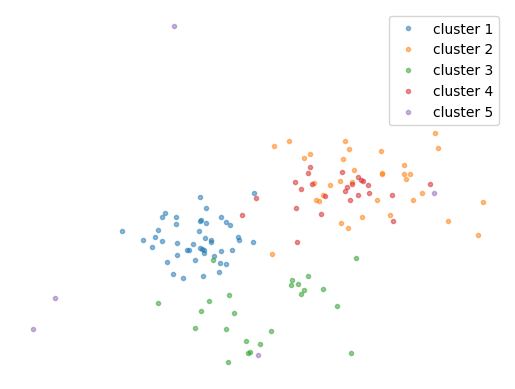

In [ ]:
# REF: https://h1ros.github.io/posts/make-simulated-data-for-clustering/
import pandas as pd

# 5 clusters in M-D
# means
cl1_m = np.array( np.random.randint(10, size=(M)) + 2 )
cl2_m = np.array( np.random.randint(10, size=(M)) + 5)
cl3_m = np.array( np.random.randint(10, size=(M)) - 3 )
cl4_m = np.array( np.random.randint(10, size=(M)) + 8 )
# cl5_m = np.array( np.random.randint(10, size=(M)) - 4 )
outliers_m = np.array( np.random.randint(5, size=(M)) - 5 ) # outliers


# Add sparse outliers as extremely large covariance
# arr = np.random.multivariate_normal(5, 40, 5)


d_means = {'cluster 1': cl1_m, 
           'cluster 2': cl2_m, 
           'cluster 3': cl3_m,
           'cluster 4': cl4_m,
           'cluster 5' : outliers_m}
#           'cluster 5': cl5_m}

# covariances
cl1_c = np.array( np.random.randint(3, size=(M, M)) )
cl2_c = np.array( np.random.randint(5, size=(M, M)) )
cl3_c = np.array( np.random.randint(5, size=(M, M)) )
cl4_c = np.array( np.random.randint(3, size=(M, M)) )
# cl5_c = np.array( np.random.randint(4, size=(M, M)) )
outliers_c = np.array( np.random.randint(100, size=(M, M)) )
# print(cl1_m)          

d_covs = {'cluster 1': cl1_c, 
          'cluster 2': cl2_c, 
          'cluster 3': cl3_c,
          'cluster 4': cl4_c,
          'cluster 5': outliers_c}
#          'cluster 5': cl5_c}


# Generate data based on the above parameters
# n_data = np.array( [42, 26, 26, 18, 18] )    # 5 clusters
n_data = np.array( [46, 35, 24, 25, 5] )          # 4 clusters (then, add 10 sparse outliers)

# Generate data based on the above parameters
X = []
l = []
i = 0
for cluster in d_means.keys():       
    Ncl = n_data[i]
    i=i+1 
    arr = np.random.multivariate_normal(d_means[cluster], d_covs[cluster], Ncl)
    df_tmp = pd.DataFrame(arr)
    X_tmp = df_tmp.to_numpy()
    if i==1:
      X = X_tmp
    else:
      X = np.concatenate( [X, X_tmp] )
    df_tmp['label'] = cluster
    l.append(df_tmp)    
    plt.plot(df_tmp[3], df_tmp[5], '.', label=cluster, alpha=0.5)

plt.legend()
plt.axis('off')
plt.show()

In [ ]:
'''
# Transform from df to numpy array
X_tmp = df_tmp.to_numpy()
X = (X_tmp[:,0:M]).astype(float)
np.shape(X)
'''

(18, 10)

In [ ]:
print(X)
np.shape(X)

[[ 12.32263178   4.94023463   2.34014821 ...  11.23013247   2.04528724
    5.12246195]
 [  9.74925826  -0.01690724   2.1164944  ...   5.61524213   2.29743968
    1.95796034]
 [  9.98688846   2.20636548   2.56497488 ...   7.13083014   2.43942846
    3.5535258 ]
 ...
 [  6.15414469   3.38686098  -7.34285335 ...  -8.02313847  -9.92056529
    2.44890841]
 [  2.31825091  -6.5532601   -2.51243154 ...   1.53646866 -10.46461794
  -11.80179175]
 [  7.04266017   8.43853326   6.501636   ...  -6.93482678  -3.99827074
   -2.26128625]]


(135, 14)

In [ ]:
# np.save("Dataset_lab0506.npy", X)
np.save("Dataset_lab07.npy", X)

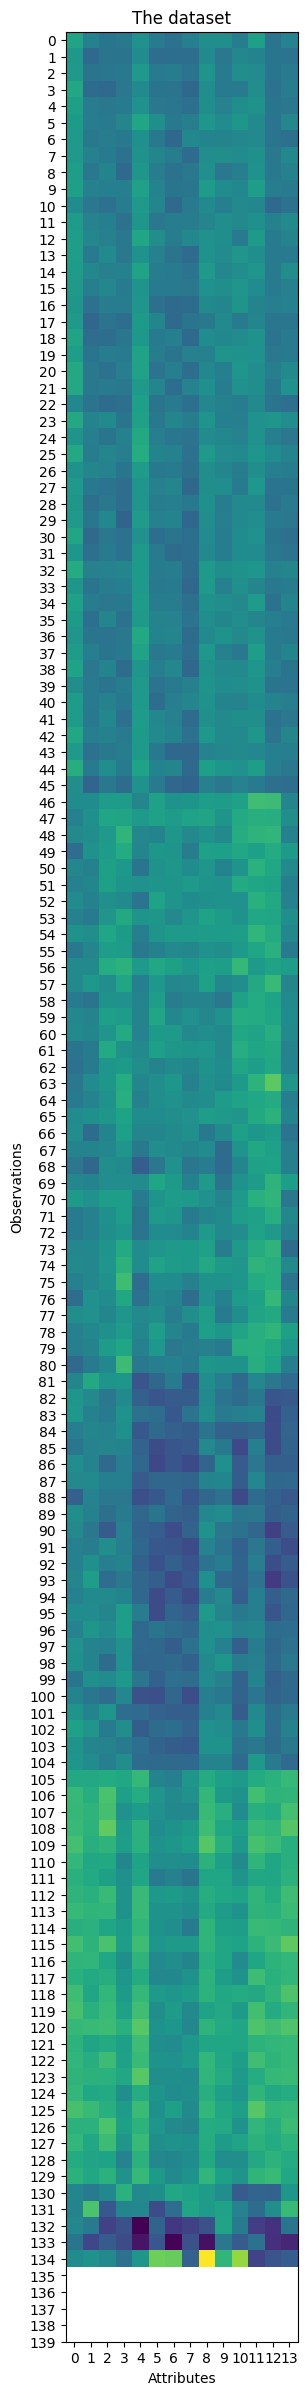

NameError: ignored

<Figure size 1000x500 with 0 Axes>

In [ ]:
# Visualization
# -------------


# 2D image of the entire dataset
# X2plot = (X[:,0:M]).astype(float)
fig1 = plt.figure(figsize=(5, 30))
plt.imshow(X)
vmin = np.min(X)
vmax = np.max(X)
plt.clim(vmin, vmax)
plt.xlabel('Attributes')
plt.xticks(np.arange(0, M, step=1))
plt.ylabel('Observations')
plt.yticks(np.arange(0, N, step=1))
plt.title('The dataset')
# plt.colorbar()
plt.show()


# Scatterplot using two random features
feat1 = 2
feat2 = 8
fig2 = plt.figure('Check the dataset', figsize=(10,5)) 
# sns.scatterplot( x = X[:,feat1], y = X[:,feat2], hue=TRUElabels)
sns.set_theme(style='dark')
plt.xlabel('Attribute no.%s' % feat1)
plt.ylabel('Attribute no.%s' % feat2)
plt.grid()
plt.show()

In [ ]:
import pandas as pd

# 5 clusters in 2D
d_means = {'cluster 1': [0, 0, 0], 
           'cluster 2': [4, 5, 3], 
           'cluster 3': [5, 0, 2],
           'cluster 4': [2, 8, 4],
           'cluster 5': [1, 3, 2]}

d_covs = {'cluster 1': [[1, 1, 1], 
                        [1, 4, 2],
                        [1, 2, 2]], 
          'cluster 2': [[1, 1, 1], 
                        [1, 3, 2],
                        [0.5, 2, 1.5]], 
          'cluster 3': [[4, 2, 3], 
                        [2, 2, 3],
                        [1, 1, 4]],
          'cluster 4': [[3, 3, 3], 
                        [5, 1.5, 2],
                        [2, 1, 2]],
          'cluster 5': [[3, 1, 1],
                        [5, 3, 2], 
                        [2, 2, 2]]}


# Generate data based on the above parameters
n_data = 130

# Generate data based on the above parameters
l = []
for cluster in d_means.keys():
    arr = np.random.multivariate_normal(d_means[cluster], d_covs[cluster], n_data)
    df_tmp = pd.DataFrame(arr)
    df_tmp['label'] = cluster
    l.append(df_tmp)
    plt.plot(df_tmp[0], df_tmp[1], '.', label=cluster, alpha=0.5)

plt.legend()
plt.axis('off')
plt.show()

In [ ]:
# Simulate 5 classes
K = 5
X = X+np.abs(np.min(X))
i = int(np.floor(N/2))
X[0:i+1,:]   = ( X[0:i+1,:]  *(-10) - 5 ).round(2)
X[i+1:N+1,:] = ( X[i+1:N+1,:]*10    + 7 ).round(2)

In [ ]:
# Compute S manually

# A is the mean intra-cluster distance
A = sum( D[np.triu_indices_from(D, k=1)])
print(A.round(2))

# Compute B: mean nearest-cluster distance for every sample

# Visualize silhouette score

**Individual Silhouette Coefficient**: computation of the silhouette coefficient (_s_) for each sample.

The individual silhouette coefficient for one individual sample is:
$$
s = \frac{b-a}{max(a,b)}
$$

where _a_ is the mean distance between a sample and all other points in the same class (note: it could be slightly different from the distance between the sample and its centroid), and _b_ is the mean distance between the sample and all other points in the nearest cluster that the sample is not a part of.

To compute the individual silhouette coefficient, use _silhouette_samples_.

See [individual silhouette score (documentation)](https://scikit-learn.org/stable/modules/generated/sklearn.metrics.silhouette_samples.html#sklearn.metrics.silhouette_samples).

In [ ]:
# Compute the Silhouette Score
from sklearn.metrics import silhouette_samples
s = silhouette_samples(X, labels)
print(*s.round(3))

0.403 0.233 0.433 0.019 0.362 0.139 0.291 0.186 0.403 0.184 0.33 -0.057 0.29 0.433 0.362


In [ ]:
# Visualize silhouette values. REF: https://scikit-learn.org/stable/auto_examples/cluster/plot_kmeans_silhouette_analysis.html
# For general plots, see also: https://www.geeksforgeeks.org/how-to-add-axes-to-a-figure-in-matplotlib-with-python/
from yellowbrick.cluster import SilhouetteVisualizer
import numpy as np
import matplotlib.cm as cm
import matplotlib.pyplot as plt


# Create figure() objects
# This acts as a container for the different plots
fig = plt.figure()
  
# Creating axis
# add_axes([xmin,ymin,dx,dy])
axes = fig.add_axes([0.5, 1, 0.5, 1])
  
# Depict illustration
fig.show()


# The 1st subplot is the silhouette plot
# The silhouette coefficient can range from -1, 1 but in this example all ly within [-0.1, 1]
ax1.set_xlim([-0.1, 1])
# The (n_clusters+1)*10 is for inserting blank space between silhouette
# plots of individual clusters, to demarcate them clearly.
ax1.set_ylim([0, len(X) + (labels.max() + 1) * 10])

y_lower = 10
for i in range(labels.max()):
    # Aggregate the silhouette scores for samples belonging to
    # cluster i, and sort them
    ith_cluster_silhouette_values = s[labels == i]

    ith_cluster_silhouette_values.sort()

    size_cluster_i = ith_cluster_silhouette_values.shape[0]
    y_upper = y_lower + size_cluster_i

    color = cm.nipy_spectral(float(i) / labels.max())
    ax1.fill_betweenx(
        np.arange(y_lower, y_upper),
        0,
        ith_cluster_silhouette_values,
        facecolor=color,
        edgecolor=color,
        alpha=0.7,
    )

    # Label the silhouette plots with their cluster numbers at the middle
    ax1.text(-0.05, y_lower + 0.5 * size_cluster_i, str(i))

    # Compute the new y_lower for next plot
    y_lower = y_upper + 10  # 10 for the 0 samples

ax1.set_title("The silhouette plot for the various clusters.")
ax1.set_xlabel("The silhouette coefficient values")
ax1.set_ylabel("Cluster label")

# The vertical line for average silhouette score of all the values
ax1.axvline(x=S, color="red", linestyle="--")

ax1.set_yticks([])  # Clear the yaxis labels / ticks
ax1.set_xticks([-0.1, 0, 0.2, 0.4, 0.6, 0.8, 1])

# 2nd Plot showing the actual clusters formed
colors = cm.nipy_spectral(labels.astype(float) / labels.max())
ax2.scatter(
    X[:, 0], X[:, 1], marker=".", s=30, lw=0, alpha=0.7, c=colors, edgecolor="k"
)

# **Step 4**: Visualize this clustering solution using the dendrogram

To visualize the dendrogram, you can use the following code:

```
# Dendrogram
from scipy.cluster.hierarchy import dendrogram

```

See [dendrogram documentation](https://scikit-learn.org/stable/auto_examples/cluster/plot_agglomerative_dendrogram.html#sphx-glr-auto-examples-cluster-plot-agglomerative-dendrogram-py).

In [ ]:
from scipy.cluster.hierarchy import dendrogram
fig5 = plt.plot(figsize=(20,5))
# dendrogram(clustering.distances_, labels=clustering.labels_, leaf_rotation=90, leaf_font_size=10)
linkage_matrix = np.column_stack(
        [clustering.children_, clustering.distances_]
    ).astype(float)

# Plot the corresponding dendrogram
dendrogram(linkage_matrix)

'\nfig, ax = plt.subplots(1,4, figsize=(20,3))\nfig.subplots_adjust(hspace=0.5)\n\nlinkages = [\'single\', \'complete\', \'average\', \'ward\']\nfor link, axis in zip(linkages, fig.axes):\n  hc = linkage(y = X_transformed, method=link, metric=distance_metric) \n  axis.set_title("Linkage=%s" % link, size=15)\n  axis.set_xlabel(\'Sample Type\', size=15)\n  axis.set_ylabel(\'Distance\', size=15)    \n  dendrogram(hc, ax=axis, labels=TRUElabels, leaf_rotation=90, leaf_font_size=10)\n'

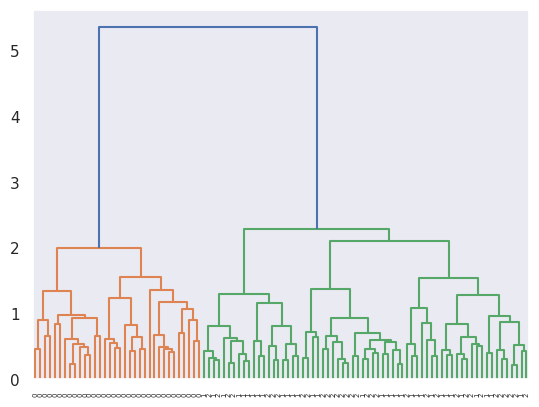

In [ ]:
from scipy.cluster import hierarchy
from scipy.cluster.hierarchy import linkage
from scipy.cluster.hierarchy import dendrogram

fig6 = plt.plot(figsize=(20,5))
hc = linkage(y = X_transformed, method='ward', metric=distance_metric) 
dendrogram(hc, labels=TRUElabels, leaf_rotation=90, leaf_font_size=5)


'''
fig, ax = plt.subplots(1,4, figsize=(20,3))
fig.subplots_adjust(hspace=0.5)

linkages = ['single', 'complete', 'average', 'ward']
for link, axis in zip(linkages, fig.axes):
  hc = linkage(y = X_transformed, method=link, metric=distance_metric) 
  axis.set_title("Linkage=%s" % link, size=15)
  axis.set_xlabel('Sample Type', size=15)
  axis.set_ylabel('Distance', size=15)    
  dendrogram(hc, ax=axis, labels=TRUElabels, leaf_rotation=90, leaf_font_size=10)
'''

# **Step 5**: Compute cluster centers and find the labels

Hint: To compute centers, you may want to use the code already developed for Lab02.

In [ ]:
from scipy.spatial.distance import pdist as pdist
from scipy.spatial.distance import squareform as sf

METRIC = 'euclidean'
labels = clustering.labels_


PM = pdist(X_transformed_reduced, metric=METRIC)
PM = sf(PM).round(2)

# [NEW CORRECTED CODE!!] Intra-cluster distances (average over all pairwise distances) -----------------
# You could alternatively compute this measure as the average distance of all points from its centroid.
d = np.zeros(K)
for k in range(K):    
  ind = np.array( np.where(labels == k ) )  
  for r in range(ind.size):
    d[k] = d[k] + np.sum( PM[ [ind[0][r]], [ind] ] )
  d[k] = d[k]/2                                          # not to consider pairs of pair-wise distance between objects twice (the PM is symmetric)
  d[k] = d[k]/( (ind.size*(ind.size-1)) / 2 )            # to compute the average among N*(N-1)/2 possible unique pairs
print("The intra-cluster distance of the three clusters are: ", d.round(2))
# ------------------ CORRECTED CODE FOR INTER-CLUSTER DISTANCE --------------------------------


# Find centers
centers = np.zeros((K,2))
print("\nWe need to compute %d centroids, as we have %d clusters." % (K, K) )
for k in range(0, K):
  ind = np.array( np.where(labels == k ) )  
  cluster_points = X_transformed_reduced[ind, :][0]
  centers[k,:] = cluster_points.mean(axis=0)  
  print("The centroid of cluster %d has coordinates: " % k, *centers[k,:].round(2))



# Inter-cluster distance
D = pdist(centers, metric=METRIC)
D = sf(D).round(2)  

print("\nThe inter-cluster distances are:\n |dist(C_0,C_1)| = %.2f \n |dist(C_0,C_2)| = %.2f \n |dist(C_1,C_2)| = %.2f " % (D[0,1].round(2), D[0,2].round(2), D[1,2].round(2)))

The intra-cluster distance of the three clusters are:  [0.26 0.28 0.14]

We need to compute 3 centroids, as we have 3 clusters.
The centroid of cluster 0 has coordinates:  0.34 0.71
The centroid of cluster 1 has coordinates:  0.58 0.4
The centroid of cluster 2 has coordinates:  0.8 0.72

The inter-cluster distances are:
 |dist(C_0,C_1)| = 0.39 
 |dist(C_0,C_2)| = 0.46 
 |dist(C_1,C_2)| = 0.38 


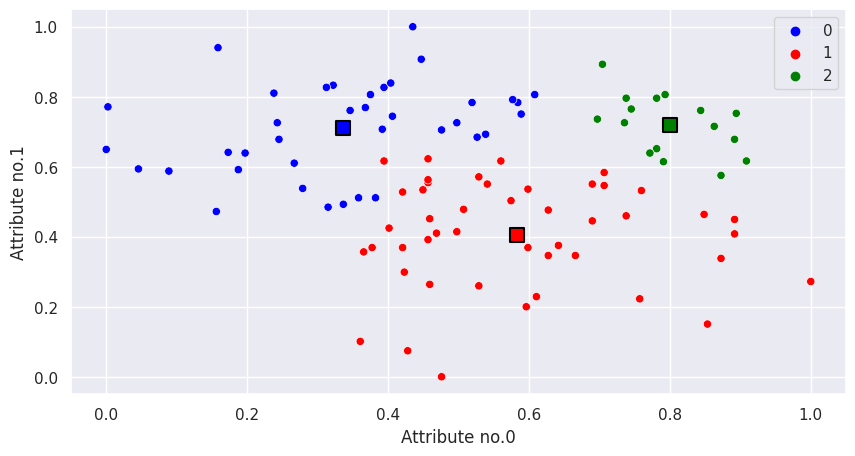

In [ ]:
# Scatterplot with random choice of the features to represent the dataset
fig3 = plt.figure('Hierarchical clustering', figsize=(10,5)) 
PAL = ['blue', 'red', 'green']
sns.scatterplot(x=X_reduced[:,feat1], y=X_reduced[:,feat2], hue=clustering.labels_, palette=PAL)
for k in range(K):
  plt.scatter(x=centers[k,0], y=centers[k,1], s=100, color=PAL[k], marker='s', edgecolor='black', linewidth=1.5)
sns.set_theme(style='dark')
plt.xlabel('Attribute no.%d' % feat1)
plt.ylabel('Attribute no.%d' % feat2)
plt.grid()
plt.show()

Compute intra-cluster distances and inter-cluster distances

* Intra-cluster distance as Euclidean distance
* Inter-cluster distance can be computed using the MIN, MAX, GROUP AVERAGE, CENTROIDS, Ward's distance

In [ ]:
## For each cluster, group instances of that cluster (as assigned by the clustering just above)

# Define list A as array with the mean distance values of every cluster
import numpy as np
A = [0] * labels.max()

# Define lists B as arrays with the mean distance values of every cluster,
# one B array for each possible def of inter-cluster distance
# B_MIN = [0] * labels.max()
# B_MAX = [0] * labels.max()
# B_AVG = [0] * labels.max()
# B_CEN = [0] * labels.max()
# B_WAR = [0] * labels.max()

# Loop on the clusters to compute the average intra-cluster distance
for n_clusters in range(1, labels.max()+1): # stop value of range not included
  Xcurr = X[labels==n_clusters]             # instances assigned to the current cluster  

  # compute the distances between each pair of instances within the current cluster
  Dcurr = pdist(Xcurr, distance_metric)
  Dcurr = sf(Dcurr).round(2)
  # print(Dcurr)

  # Compute A (ATTENTION: REMOVE THE DIAGONAL)
  Atmp = Dcurr[np.triu_indices_from(Dcurr, k=1)]
  # print(*Atmp)

  A[n_clusters-1] = (Atmp.mean()).round(3)

  print( 'Cluster no.%d has %d items and intra-cluster distance A = %3f.' % (n_clusters, Xcurr.size, (Atmp.mean()).round(3) ) )

#print(A)

Cluster no.1 has 48 items and intra-cluster distance A = 1.264000.
Cluster no.2 has 42 items and intra-cluster distance A = 1.414000.


1. Compute the PROXIMITY MATRIX

In [ ]:
# Compute the PROXIMITY MATRIX (i.e., distance between rows of X)
D = pdist(X, distance_metric)
D = sf(D).round(2)
print(D.shape)

(100, 100)


In [ ]:
'''
# Apply clustering
from sklearn.cluster import AgglomerativeClustering

clustering = AgglomerativeClustering(metric=distance_metric, linkage=method_merging, compute_distances=True).fit(X_transformed_reduced)
'''

# Manual clustering evaluation

In [ ]:
def clustering_evaluation(X, K, METRIC, labels):

  '''
  INPUT
  X       - data matrix for which to compute the proximity matrix
  K       - number of desired clusters
  centers - cluster centres from the clustering solution applied to X
  labels  - predicted labels from the clustering solution applied to X
  '''

  '''
  OUTPUT
  PM      - proximity matrix computed on X (using euclidean distance metric)
  centers - cluster centres from the clustering solution applied to X, with K clusters
  d       - average distance between pairs of objects in each cluster
  D       - inter-cluster distances
  '''

  from scipy.spatial.distance import pdist as pdist
  from scipy.spatial.distance import squareform as sf

  # METRIC = 'euclidean'
  PM = pdist(X, metric=METRIC)
  PM = sf(PM).round(2)

  # [NEW CORRECTED CODE!!] Intra-cluster distances (average over all pairwise distances) -----------------
  # You could alternatively compute this measure as the average distance of all points from its centroid.
  d = np.zeros(K)
  for k in range(K):    
    ind = np.array( np.where(labels == k ) )  
    for r in range(ind.size):
      d[k] = d[k] + np.sum( PM[ [ind[0][r]], [ind] ] )
    d[k] = d[k]/2                                          # not to consider pairs of pair-wise distance between objects twice (the PM is symmetric)
    d[k] = d[k]/( (ind.size*(ind.size-1)) / 2 )            # to compute the average among N*(N-1)/2 possible unique pairs
  print("The intra-cluster distance of the three clusters are: ", d.round(2))
  # ------------------ CORRECTED CODE FOR INTER-CLUSTER DISTANCE --------------------------------


  # Find centers
  centers = np.zeros((2,K))
  print("We need to compute %d centroids, as we have %d clusters.\n" % (K, K) )
  for k in range(0,1): #range(0, K):
    ind = np.array( np.where(labels == k ) )
    print(ind)
    cluster_points = np.array( X[ind, :] ) #df.loc[df['Class'] == k]    
    print(np.shape(cluster_points))
    print(cluster_points.mean(axis=0))
    centers[k,:] = np.array( cluster_points.mean(axis=1) )
    # centers[k][:] = np.array( cluster_points.mean(axis=0) )
    print("The centroid of cluster %d has coordinates: " % k, *centers[k][:], "\n")



  # Inter-cluster distance
  D = pdist(centers, metric=METRIC)
  D = sf(D).round(2)  

  print("The inter-cluster distances are:\n |dist(C_0,C_1)| = %.2f \n |dist(C_0,C_2)| = %.2f \n |dist(C_1,C_2)| = %.2f " % (D[0,1].round(2), D[0,2].round(2), D[1,2].round(2)))

  return PM, centers, d, D

In [ ]:
# Use the function just defined to evaluate the clustering solution in terms of distances within- and between-clusters
PM, centers, d, D = clustering_evaluation(X_transformed_reduced, K, distance_metric, TRUElabels)

In [ ]:
from scipy.cluster.hierarchy import cut_tree

hc = linkage(y = X, method=method_merging, metric=distance_metric)

nci_hc_complete_4_clusters = cut_tree(hc, n_clusters = 4) # Printing transpose just for space

pd.crosstab(index = X.index, 
            columns = nci_hc_complete_4_clusters.T[0], 
            rownames = ['Class type'], 
            colnames = ['Cluster'])

In [ ]:
# Import useful packages
from scipy.cluster.hierarchy import dendrogram
import matplotlib.pyplot as plt
%matplotlib inline
#the latter makes the plots generated by matplotlib show into the IPython shell that we are running and not in a separate output window

# Visualize the DENDROGRAM of the corresponding clustering
plt.figure(figsize=(8, 5))
dn = hierarchy.dendrogram(Z, labels=names.tolist(), orientation='right', no_plot=0)
# dn = hierarchy.dendrogram(Z, orientation='right', no_plot=0)
plt.xlabel('Distance');

# Plot a vertical line indicating the cut
plt.axvline(x=max_d, color='k', linestyle='--')
plt.show()

In [ ]:
# IMPORT THE TRUE LABELS AND COMPARE THEM WITH THE BEST CLUSTERING SOLUTION
ind1 = int(np.floor(N/3))
ind2 = int(np.floor(N/3)) + ind1
a1  = np.array( [int(0) for j in range(0,ind1+1)] )
a2  = np.array( [int(1) for j in range(ind1+1,ind2+1)] )
a3  = np.array( [int(2) for j in range(ind2+1,N)] )
TRUElabels = np.concatenate( [a1, a2, a3] )

In [ ]:
# IMPORT THE TRUE LABELS AND COMPARE THEM WITH THE BEST CLUSTERING SOLUTION
ind1 = int(np.floor(N/3))
ind2 = int(np.floor(N/3)) + ind1
a1  = np.array( [int(0) for j in range(0,ind1+1)] )
a2  = np.array( [int(1) for j in range(ind1+1,ind2+1)] )
a3  = np.array( [int(2) for j in range(ind2+1,N)] )
TRUElabels = np.concatenate( [a1, a2, a3] )

# (OPTIONAL) Limitations of hierarchical clustering

You can load the **NAME dataset**, and run the hierarchical clustering again.

Comment on what limitations you observe in the application of hierarchical clustering in this case.

### Dendrogram + re-ordered dataset

In [ ]:
fig = pylab.figure(figsize=(8,8))

axmatrix = fig.add_axes([0.3,0.1,0.6,0.6])
idx1 = Z['leaves']
idx2 = Z['leaves']


ax1 = fig.add_axes([0.09,0.1,0.2,0.6])
axmatrix = fig.add_axes([0.3,0.1,0.6,0.6])
#idx1 = Z_single['leaves']
#idx2 = Z_complete['leaves']

#D = squareform(X.values)
#D = D[idx1,:]
#D = D[:,idx2]
im = axmatrix.matshow(sf(Z), aspect='auto', origin='lower', cmap=pylab.cm.YlGnBu)
axmatrix.set_xticks([])
axmatrix.set_yticks([])

#mm = pdist(Z, metric='euclidean') #input = m by n array of m original observations in an n-dimensional space
#mm2 = sf(mm, force = 'tomatrix')
#mm2[1:3, 1:3]

#print("Print the 15x15 proximity matrix")
#distance_matrix_SINGLE = linkage(Z1[['mammals', 'non-mammals']], method='complete')
#distance_matrix_SINGLE




### Plot the flat clusters

In [ ]:
# Plot clusters
import seaborn as sns
import matplotlib.pyplot as plt

x = X[ ["Warm-blooded", "Gives Birth"] ];
# print(X)
print(x)  # X[::3] --> takes every 3 rows, all columns
plt.figure(figsize=(8, 5))
sns.scatterplot(data='x', hue='labels')
plt.imshow()


# Define a colors dictionary for clusters
colors = {1:'red', 2:'blue'}

# Plot the scatter plot
# X.plot.scatter(x='x_scaled', y='y_scaled', c=comic_con['cluster_labels'].apply(lambda x: colors[x]));

In [ ]:
# Create a confusion matrix to compare the differences in how the two methods (KMeans vs Hierarchical) assigned observations to clusters:
# kmean_4 = KMeans(n_clusters = 4, random_state = 123, n_init = 150)    
# kmean_4.fit(nci_data)
# kmean_4.labels_

# pd.crosstab(index = kmean_4.labels_, 
#             columns = nci_hc_complete_4_clusters.T[0], 
#             rownames = ['K-Means'], 
#             colnames = ['Hierarchical'])
#
# REF: http://www.science.smith.edu/~jcrouser/SDS293/labs/lab16-py.html

# PROVE/ALTRE CONSIDERAZIONI
Comparison of runtime of linkage method

Increasing runtime with data points

Quadratic increase of runtime

Not feasible for large datasets

Other evaluations:
* compute the _between-cluster distance_
* compute the _within-cluster distance_

**Elbow method**
The previous method can be inconsistent, then let us use the elbow method.

[REF: https://joernhees.de/blog/2015/08/26/scipy-hierarchical-clustering-and-dendrogram-tutorial/#Selecting-a-Distance-Cut-Off-aka-Determining-the-Number-of-Clusters]

In [ ]:
# last = Z2[-10:, 2]
# last_rev = last[::-1]
# idxs = np.arange(1, len(last) + 1)
# plt.plot(idxs, last_rev)

# acceleration = np.diff(last, 2)  # 2nd derivative of the distances
# acceleration_rev = acceleration[::-1]
# plt.plot(idxs[:-2] + 1, acceleration_rev)
# plt.show()
# k = acceleration_rev.argmax() + 2  # if idx 0 is the max of this we want 2 clusters
#print "clusters:", k

**Classification via hierarchical clustering**
Step 1: cut the tree, i.e., decide the number of clusters
Step 2: assign the corresponding label to the entries

Now, let us assume to classify the entries in two classes ("mammals"/"non-mammals"), using the complete-linkage hierarchical clustering algorithm and cut the corresponding tree at a distance equal to 2.

Note. To visualize the result in 2D, we need to limit the representation of the entries to two features, only. Let us use "Aquatic Creature" and "Aerial Creature".

[REF: https://www.analyticsvidhya.com/blog/2019/05/beginners-guide-hierarchical-clustering/]

In [ ]:
# Decide the 'METHOD' and the 'METRIC'


# ALTERNATIVA
# from sklearn.cluster import AgglomerativeClustering
# cluster = AgglomerativeClustering(n_clusters=2, affinity='euclidean', linkage='ward')  
# cluster.fit_predict(X.values)
#
# ALTRA ALTERNATIVA
# REF: https://joernhees.de/blog/2015/08/26/scipy-hierarchical-clustering-and-dendrogram-tutorial/#Selecting-a-Distance-Cut-Off-aka-Determining-the-Number-of-Clusters
# from scipy.cluster.hierarchy import fcluster
# clusters = fcluster(Z2, max_d, criterion='distance')
# clusters


# Create a DataFrame with labels and varieties as columns: df
df = pd.DataFrame({'labels': labels, 'varieties': Y})

# Create crosstab
ct = pd.crosstab(df['labels'], df['varieties'], rownames=['Actual'], colnames=['Predicted'])


# Display confusion matrix
print(ct)

# REF: https://datatofish.com/confusion-matrix-python/

Predicted  mammals  non-mammals
Actual                         
1                0            8
2                5            2


In [ ]:
# Visualize the entire y_predicted ("labels") and y_actual ("varieties")
df

In [ ]:
## CHECK CALCOLO DISTANZE EUCLIDEE
# from sklearn.metrics.pairwise import euclidean_distances
# import numpy as np
# from math import sqrt
# human  = np.array([1, 1, 0, 0, 1, 0])
# python = np.array([0, 0, 0, 0, 0, 1])
# salmon = np.array([0, 0, 1, 0, 0, 0])

# print( np.sqrt(np.sum( human * human - 2 * human * python + python * python)) )
# print( np.sqrt(np.sum( human * human - 2 * human * salmon + salmon * salmon)) )
# print( np.sqrt(np.sum( salmon * salmon - 2 * salmon * python + python * python)) )

# print( human*human )

# print( human*python )

# print( python*python )

# print( human*human + python*python )
# print( np.sum(human*human + python*python) )

**Extracting the cluster labels**
Now, use the _fcluster()_ function to extract the cluster labels for this intermediate clustering, and compare the labels with the actual classes using a cross-tabulation.
[REF: https://goodboychan.github.io/python/datacamp/machine_learning/visualization/2020/06/01/02-Visualization-with-hierarchical-clustering-and-t-SNE.html]

In [ ]:
# Assign cluster labels to each row of data
X['cluster_labels'] = fcluster(Z, 2, criterion='maxclust')

# Display cluster centers of each cluster
print(X[['scaled_sliding_tackle', 'scaled_aggression', 'cluster_labels']].groupby('cluster_labels').mean())

# Create a scatter plot through seaborn
sns.scatterplot(x='scaled_sliding_tackle', y='scaled_aggression', hue='cluster_labels', data=X.values)
#plt.savefig('../images/fifa_cluster.png')

**Timing run of hierarchical clustering**
REF: https://colab.research.google.com/github/goodboychan/chans_jupyter/blob/master/_notebooks/2020-06-06-02-Hierarchical-Clustering.ipynb#scrollTo=9AWSkYlixQvr

You can time the execution of small code snippets with, e.g., _%timeit sum([1, 3, 2])_

In [ ]:
%timeit linkage(X_values, method='ward', metric='euclidean')

You can also download other datasets, e.g. the [Iris dataset](http://archive.ics.uci.edu/ml/machine-learning-databases/iris/iris.data), from the UCI machine learning repository.

<ipython-input-66-5b9b2643e2c9>:7: DeprecationWarning: scipy.rand is deprecated and will be removed in SciPy 2.0.0, use numpy.random.rand instead
  x = scipy.rand(40)
<ipython-input-66-5b9b2643e2c9>:8: DeprecationWarning: scipy.zeros is deprecated and will be removed in SciPy 2.0.0, use numpy.zeros instead
  D = scipy.zeros([40,40])


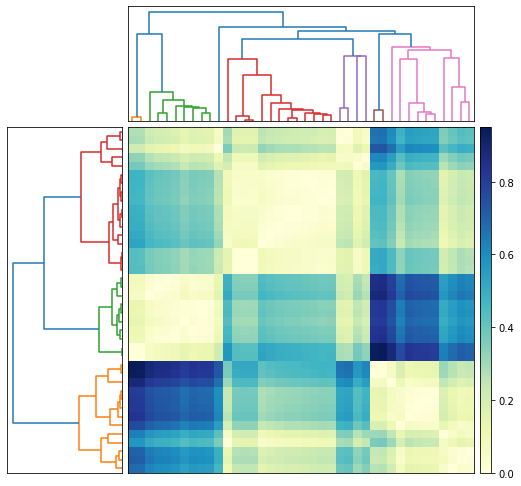

In [ ]:
import scipy
import pylab
import scipy.cluster.hierarchy as sch
from scipy.spatial.distance import squareform

# Generate random features and distance matrix.
x = scipy.rand(40)
D = scipy.zeros([40,40])
for i in range(40):
    for j in range(40):
        D[i,j] = abs(x[i] - x[j])
condensedD = squareform(D)
condensedD.shape


# Compute and plot first dendrogram
fig = pylab.figure(figsize=(8,8))
ax1 = fig.add_axes([0.09,0.1,0.2,0.6])
Y = sch.linkage(condensedD, method='centroid')
Z1 = sch.dendrogram(Y, orientation='left')
ax1.set_xticks([])
ax1.set_yticks([])

# Compute and plot second dendrogram.
ax2 = fig.add_axes([0.3,0.71,0.6,0.2])
Y = sch.linkage(condensedD, method='single')
Z2 = sch.dendrogram(Y)
ax2.set_xticks([])
ax2.set_yticks([])

# Plot distance matrix.
axmatrix = fig.add_axes([0.3,0.1,0.6,0.6])
idx1 = Z1['leaves']
idx2 = Z2['leaves']
D = D[idx1,:]
D = D[:,idx2]
im = axmatrix.matshow(D, aspect='auto', origin='lower', cmap=pylab.cm.YlGnBu)
axmatrix.set_xticks([])
axmatrix.set_yticks([])

# Plot colorbar.
axcolor = fig.add_axes([0.91,0.1,0.02,0.6])
pylab.colorbar(im, cax=axcolor)
fig.show()
#fig.savefig('dendrogram.png')